# Composición del Sistema de Ahorro para el Retiro (SAR)

**Pregunta**: ¿Cuánto dinero administra el SAR mexicano y cómo se distribuye entre AFOREs y componentes?

**Dataset**: serie histórica mensual del SAR publicada por [CONSAR](https://www.gob.mx/consar) y procesada por el observatorio.

**Por qué importa**: el SAR administra los recursos de pensiones de millones de trabajadores mexicanos. Su composición y crecimiento son indicadores del sistema previsional.

## Setup

In [1]:
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from datos_mexico import DatosMexico

client = DatosMexico()
FECHA_REF = date(2025, 6, 1)  # snapshot mensual más reciente

## 1. AFOREs activas

Catálogo con código y nombre corto de cada AFORE participante.

In [2]:
afores = client.consar.afores()
df_afores = pd.DataFrame(
    [{"codigo": a.codigo, "nombre_corto": a.nombre_corto} for a in afores.afores]
)
df_afores

,codigo,nombre_corto
0,profuturo,Profuturo
1,xxi_banorte,XXI-Banorte
2,banamex,Banamex
3,sura,SURA
4,coppel,Coppel
5,pensionissste,PensionISSSTE
6,azteca,Azteca
7,principal,Principal
8,invercap,Invercap
9,inbursa,Inbursa


## 2. Total administrado y serie histórica

In [3]:
totales = client.consar.recursos_totales()
ultimo = totales.serie[-1]
print(f"Fecha más reciente: {ultimo.fecha}")
print(f"Recursos totales SAR: ${ultimo.monto_mxn_mm:,.2f} mil millones MXN")
print(f"Número de puntos en la serie: {totales.n_puntos}")
print(f"Rango: {totales.fecha_min} → {totales.fecha_max}")

Fecha más reciente: 2025-06-01
Recursos totales SAR: $10,127,978.75 mil millones MXN
Número de puntos en la serie: 326
Rango: 1998-05-01 → 2025-06-01


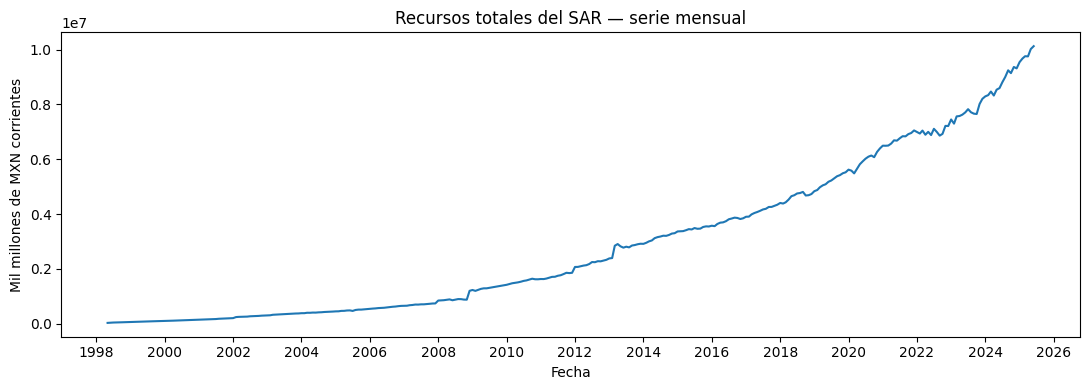

In [4]:
df_serie = pd.DataFrame(
    [{"fecha": p.fecha, "monto_mxn_mm": float(p.monto_mxn_mm)} for p in totales.serie]
)
df_serie["fecha"] = pd.to_datetime(df_serie["fecha"])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df_serie["fecha"], df_serie["monto_mxn_mm"], color="#1f77b4")
ax.set_title("Recursos totales del SAR — serie mensual")
ax.set_xlabel("Fecha")
ax.set_ylabel("Mil millones de MXN corrientes")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

El SAR ha crecido sostenidamente desde su creación en 1997 (reforma de pensiones IMSS) y 2007 (incorporación de ISSSTE). El crecimiento es nominal: incluye aportaciones nuevas, rendimientos y efecto inflacionario, sin deflactar.

## 3. Composición por AFORE en snapshot reciente

In [5]:
por_afore = client.consar.recursos_por_afore(fecha=FECHA_REF)
df_por_afore = pd.DataFrame(
    [
        {
            "afore": a.afore_nombre_corto,
            "sar_total_mm": float(a.sar_total_mm) if a.sar_total_mm else 0,
            "pct_sistema": float(a.pct_sistema) if a.pct_sistema else 0,
        }
        for a in por_afore.afores
    ]
).sort_values("sar_total_mm", ascending=False)
df_por_afore

,afore,sar_total_mm,pct_sistema
0,Profuturo,1831971.47,18.088
1,XXI-Banorte,1805554.05,17.827
2,Banamex,1577157.25,15.572
3,SURA,1575272.13,15.554
4,Coppel,800030.65,7.899
5,PensionISSSTE,755093.10,7.456
6,Azteca,591463.27,5.840
7,Principal,509593.65,5.032
8,Invercap,392892.43,3.879
9,Inbursa,258112.84,2.549


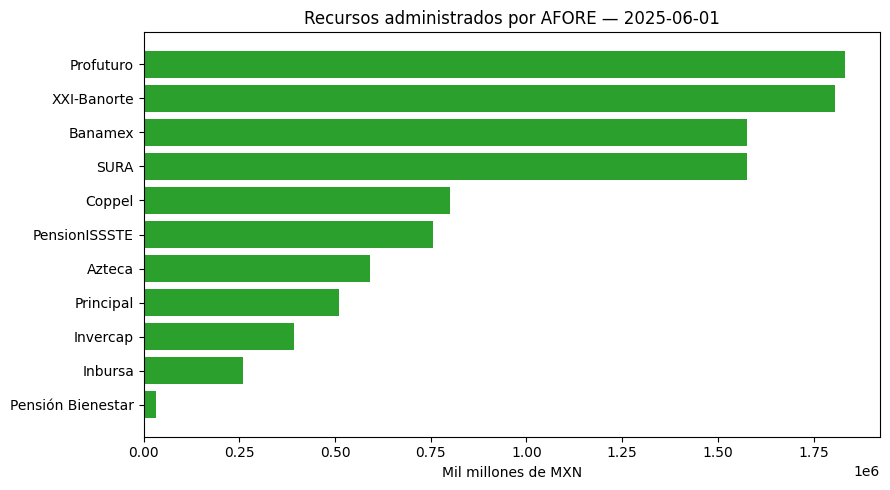

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(df_por_afore["afore"], df_por_afore["sar_total_mm"], color="#2ca02c")
ax.set_title(f"Recursos administrados por AFORE — {FECHA_REF}")
ax.set_xlabel("Mil millones de MXN")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## 4. Composición por componente

El endpoint `recursos_por_componente` devuelve datos **jerárquicos**: incluye filas resumen (`categoria='total'`), agregados intermedios (`'aggregate'`) y filas hoja (`'component'` y `'operativo'`). Para sumar componentes correctamente se filtra a las hojas.

Ver el docstring de `consar.recursos_por_componente` para detalle.

In [7]:
por_comp = client.consar.recursos_por_componente(fecha=FECHA_REF)
leaves = [c for c in por_comp.componentes if c.categoria in ("component", "operativo")]

df_comp = pd.DataFrame(
    [
        {
            "componente": c.tipo_nombre_corto,
            "categoria": c.categoria,
            "monto_mxn_mm": float(c.monto_mxn_mm),
        }
        for c in leaves
    ]
).sort_values("monto_mxn_mm", ascending=False)

print(f"SAR total declarado: {float(por_comp.sar_total_mm):,.2f} MXN mm")
print(f"Suma de hojas:       {df_comp['monto_mxn_mm'].sum():,.2f} MXN mm")
df_comp

SAR total declarado: 10,127,978.75 MXN mm
Suma de hojas:       10,127,978.75 MXN mm


,componente,categoria,monto_mxn_mm
2,RCV-IMSS,component,6256677.99
0,INFONAVIT,component,2136957.94
3,RCV-ISSSTE,component,746632.71
1,FOVISSSTE,component,258812.55
5,Ahorro Voluntario,component,197907.89
7,Fondos de Previsión Social,component,196390.71
8,Depósitos en Banxico,component,122987.40
6,Ahorro Solidario,component,83369.17
4,Bono Pensión ISSSTE,component,80880.54
9,Capital AFORES,operativo,47361.85


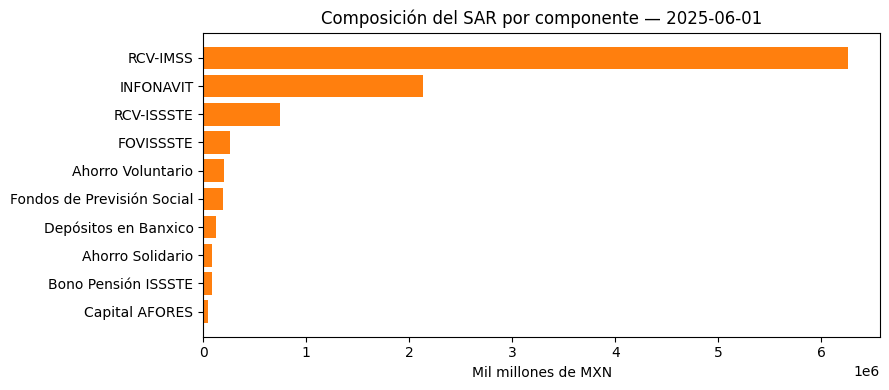

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(df_comp["componente"], df_comp["monto_mxn_mm"], color="#ff7f0e")
ax.set_title(f"Composición del SAR por componente — {FECHA_REF}")
ax.set_xlabel("Mil millones de MXN")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## 5. IMSS vs ISSSTE — series paralelas

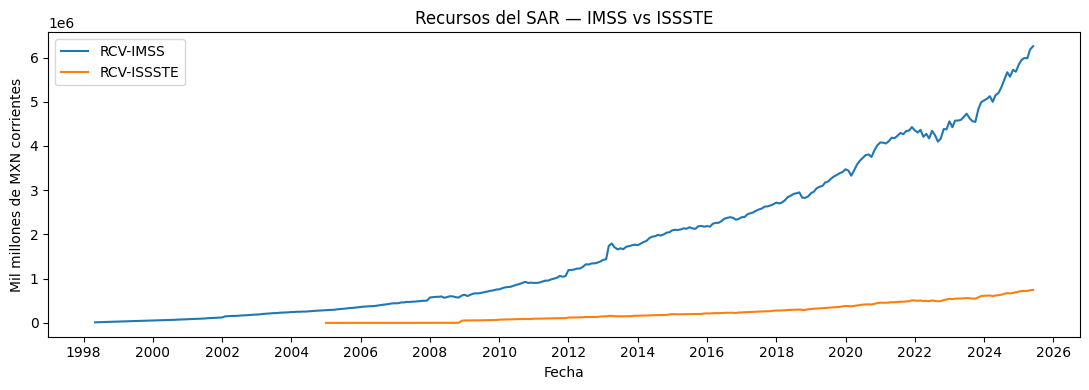

In [9]:
imss_issste = client.consar.recursos_imss_vs_issste()
df_imss_issste = pd.DataFrame(
    [
        {
            "fecha": p.fecha,
            "rcv_imss_mm": float(p.rcv_imss_mm) if p.rcv_imss_mm else None,
            "rcv_issste_mm": float(p.rcv_issste_mm) if p.rcv_issste_mm else None,
        }
        for p in imss_issste.serie
    ]
)
df_imss_issste["fecha"] = pd.to_datetime(df_imss_issste["fecha"])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df_imss_issste["fecha"], df_imss_issste["rcv_imss_mm"], label="RCV-IMSS")
ax.plot(df_imss_issste["fecha"], df_imss_issste["rcv_issste_mm"], label="RCV-ISSSTE")
ax.set_title("Recursos del SAR — IMSS vs ISSSTE")
ax.set_xlabel("Fecha")
ax.set_ylabel("Mil millones de MXN corrientes")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
fig.tight_layout()
plt.show()

## Lo que estos datos NO muestran

- **Pesos corrientes, no deflactados**: el crecimiento incluye inflación. Para análisis real se debe deflactar usando INPC.
- **No incluye rendimientos por trabajador**: las cifras son agregados del sistema, no la trayectoria de cuentas individuales.
- **No indica suficiencia de pensiones futuras**: el monto administrado hoy no predice la pensión que recibirá un trabajador específico (depende de salario, antigüedad, rendimientos futuros, comisiones, retiros parciales).
- **Antes de 1998 el SAR no existía bajo este modelo**: la serie comienza con la reforma. Pensiones del IMSS-1973 e ISSSTE-pre-2007 siguen reglas diferentes.

In [10]:
client.close()